# Resource:

* Overall notebooks: https://opentopography.org/learn/jupyter-notebooks
* bulk access: https://github.com/OpenTopography/OT_BulkAccess_COGs/blob/main/OT_BulkAccessCOGs.ipynb
* Introduction to PDAL: https://github.com/OpenTopography/Intro_to_PDAL
    * python + pdal
* python + vizualization code: https://github.com/cgre-aachen/gemgis/blob/c4b24f3e4deb84756e390642604e748ed7d4d39f/gemgis/visualization.py#L4793
    * GemGIS is a Python-based, open-source spatial data processing library.

### General imports

In [13]:
import os
import requests
import json
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# 3 public endpoints:
* `/globaldem`
* `/usgsdem`
* `/otCatalog`

In [14]:
# Server URL
# more info on server url and how it influences the base url: https://swagger.io/docs/specification/api-host-and-base-path/
server_url = "https://portal.opentopography.org/API/"

# testing out the /globaldem endpoint

In [21]:
# variables gotten from an example test execution guided with dummy data found here: 
# https://portal.opentopography.org/apidocs/#/Public/getGlobalDem
endpoint_code = "globaldem/"
demtype_code = "SRTMGL3" #The type of DEM requested is SRTMGL3.

# These coordinates define the bounding box of the area for which the DEM is requested.
south_number = "-34" # Southern boundary at latitude 50.0 degrees
north_number = "-26.5" # Northern boundary at latitude 50.1 degrees.
west_number = "-57.6" # Western boundary at longitude 14.35 degrees.
east_number = "-49" # Eastern boundary at longitude 14.6 degrees.

# The format of the output file, which should be GeoTIFF (GTiff).
output_format_code = "GTiff"

my_api_key = os.environ['OPEN_TOPO_API_KEY']

# Define the url, using the globaldem/ endpoint code. 
# should dynamic add this with f strings and kwargs in a function:
request_url = server_url + endpoint_code + "?demtype=" + demtype_code + "&south=" + south_number + "&north=" + north_number + "&west=" + west_number + "&east="+ east_number+"&outputFormat="+"output_format_code"+"&API_Key="+my_api_key
print(request_url)

https://portal.opentopography.org/API/globaldem/?demtype=SRTMGL3&south=-34&north=-26.5&west=-57.6&east=-49&outputFormat=output_format_code&API_Key=b9b85f8bb015949407cfe0f8d62d7311


In [16]:
print(type(request_url))

<class 'str'>


In [22]:
def download_dem(request_url: str, output_directory: str) -> None:
    """
    Download a DEM file from a given URL and save it to the specified output directory.

    :param request_url: The URL to download the DEM file from.
    :param output_directory: The directory to save the downloaded DEM file to.
    """
    # Make the request
    response = requests.get(request_url)
    
    # Check if the request was successful
    if response.status_code == 200:
        # Extract the filename from the response headers
        content_disposition = response.headers.get('content-disposition')
        if content_disposition:
            filename = content_disposition.split('filename=')[1].strip('"')
        else:
            filename = 'downloaded_dem.tif'
        
        # Create the full path to the output file
        output_path = os.path.join(output_directory, filename)
        
        # Write the content to the file
        with open(output_path, 'wb') as file:
            file.write(response.content)
        
        print(f"File downloaded successfully and saved to {output_path}")
    else:
        print(f"Failed to download file. Status code: {response.status_code}")
    
    #return output_path
    return output_path

# Example usage
output_directory = '../../data'
download_dem(request_url, output_directory)

File downloaded successfully and saved to ../../data/appRasterSelectAPIService17409694591531948770824.tif


'../../data/appRasterSelectAPIService17409694591531948770824.tif'

In [18]:
# Request the url
site_request = requests.get(request_url)
site_request.__dict__

{'_content': b'II*\x00\xc0\x00\x00\x00GDAL_STRUCTURAL_METADATA_SIZE=000140 bytes\nLAYOUT=IFDS_BEFORE_DATA\nBLOCK_ORDER=ROW_MAJOR\nBLOCK_LEADER=SIZE_AS_UINT4\nBLOCK_TRAILER=LAST_4_BYTES_REPEATED\nKNOWN_INCOMPATIBLE_EDITION=NO\n \x00\x13\x00\x00\x01\x03\x00\x01\x00\x00\x00\xb0\x04\x00\x00\x01\x01\x03\x00\x01\x00\x00\x00\xb0\x04\x00\x00\x02\x01\x03\x00\x01\x00\x00\x00\x10\x00\x00\x00\x03\x01\x03\x00\x01\x00\x00\x00\x05\x00\x00\x00\x06\x01\x03\x00\x01\x00\x00\x00\x01\x00\x00\x00\x15\x01\x03\x00\x01\x00\x00\x00\x01\x00\x00\x00\x1c\x01\x03\x00\x01\x00\x00\x00\x01\x00\x00\x00=\x01\x03\x00\x01\x00\x00\x00\x01\x00\x00\x00B\x01\x03\x00\x01\x00\x00\x00\x00\x01\x00\x00C\x01\x03\x00\x01\x00\x00\x00\x00\x01\x00\x00D\x01\x04\x00\x19\x00\x00\x00J\x02\x00\x00E\x01\x04\x00\x19\x00\x00\x00\xae\x02\x00\x00S\x01\x03\x00\x01\x00\x00\x00\x02\x00\x00\x00\x0e\x83\x0c\x00\x03\x00\x00\x00\xaa\x01\x00\x00\x82\x84\x0c\x00\x06\x00\x00\x00\xc2\x01\x00\x00\xaf\x87\x03\x00 \x00\x00\x00\xf2\x01\x00\x00\xb0\x87\x0c\x00\

In [9]:
# Converting the request to Python JSON object
site_json = site_request.raw.__dict__
site_json

{'headers': HTTPHeaderDict({'Date': 'Thu, 27 Feb 2025 02:16:36 GMT', 'Server': 'Apache', 'Content-Disposition': 'attachment; filename=appRasterSelectAPIService1740622596901-1772327637.tif', 'Access-Control-Allow-Origin': '*', 'Keep-Alive': 'timeout=5, max=100', 'Connection': 'Keep-Alive', 'Transfer-Encoding': 'chunked', 'Content-Type': 'application/octet-stream'}),
 'status': 200,
 'version': 11,
 'version_string': 'HTTP/1.1',
 'reason': '200',
 'decode_content': False,
 '_has_decoded_content': False,
 '_request_url': '/API/globaldem/?demtype=SRTMGL3&south=50&north=50.1&west=14.35&east=14.6&outputFormat=output_format_code&API_Key=b9b85f8bb015949407cfe0f8d62d7311',
 '_retries': Retry(total=0, connect=None, read=False, redirect=None, status=None),
 'chunked': True,
 '_decoder': None,
 'enforce_content_length': True,
 'auto_close': True,
 '_body': None,
 '_fp': <http.client.HTTPResponse at 0x7f583f5c2bc0>,
 '_original_response': <http.client.HTTPResponse at 0x7f583f5c2bc0>,
 '_fp_bytes_re

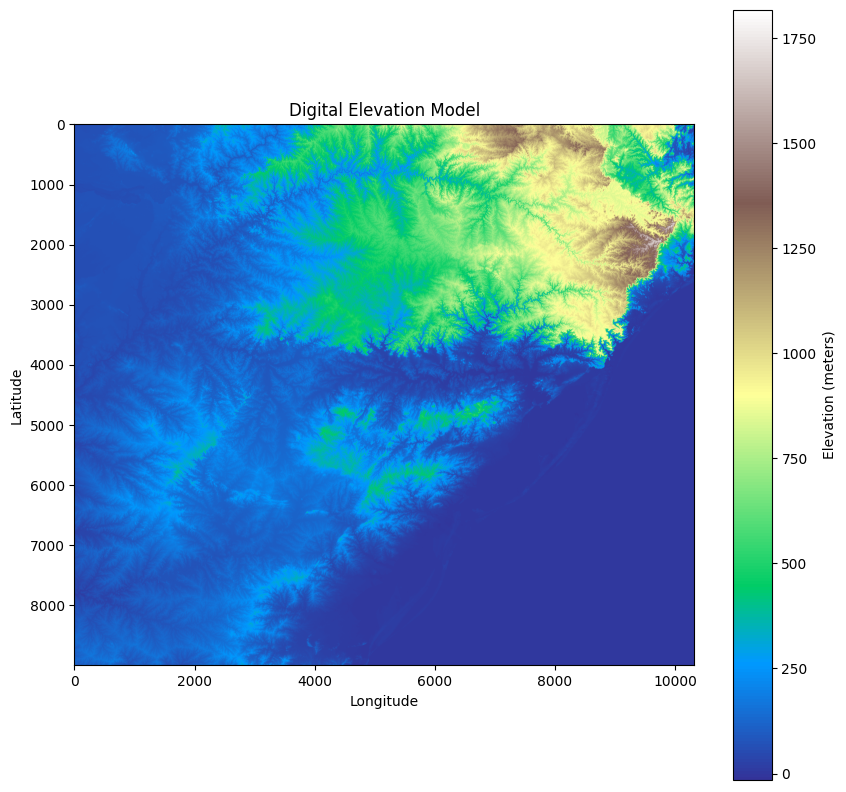

In [ ]:
# Path to the downloaded GeoTIFF file
file_path = r"/mnt/c/dev/etl_pipeline/data/appRasterSelectAPIService17409694591531948770824.tif"

# Open the GeoTIFF file
with rasterio.open(file_path) as src:
    # Read the data
    dem_data = src.read(1)
    
    # Plot the data using imshow
    plt.figure(figsize=(10, 10))
    img = plt.imshow(dem_data, cmap='terrain')
    plt.title('Digital Elevation Model')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.colorbar(img, label='Elevation (meters)')
    plt.show()

# TDL: look into https://postgis.gishub.org/chapters/geopandas.html